In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from math import sqrt

from sklearn.metrics import (mean_squared_error as MSE, mean_absolute_error as MAE, r2_score as R2,
                             explained_variance_score as EVS)
from sklearn.preprocessing import RobustScaler

from keras.models import load_model

%load_ext autoreload
%autoreload 2

%matplotlib inline

plt.rcParams['figure.figsize'] = (10, 8)

/home/bulent/anaconda3/lib/python3.6/site-packages/h5py/__init__.py:34: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters
Using TensorFlow backend.


In [2]:
def fraction_within_eps(y_true, y_pred, epsilon=0.5):
    # fraction of entries where abs(y_true - y_pred) < epsilon
    
    count = np.sum(np.abs(y_true - y_pred) <= epsilon)
    return count / y_true.shape[0]

yt = np.array([10, 10, 10, 10, 10])
yp = np.array([9.2, 9.7, 10.3, 10.2, 11])
print(fraction_within_eps(yt, yp, 0.6))
FIE = fraction_within_eps

0.6


In [3]:
def concorr(x, y):
    # Return Lin's concordance correlation coefficient
    # x, y are numpy arrays
    
    xm = x.mean()
    ym = y.mean()
    xv = x.var()
    yv = y.var()
    xycov = np.sum((x-xm)*(y-ym)) / x.shape[0]
    lin = 2*xycov / (xv + yv + (xm - ym)**2)
    return lin

xx = np.random.randn(10)
yy = xx + 10
print('R2 corr coef is {} whereas concordance corr coef is {}'.format(R2(yy,xx), concorr(yy,xx)))

R2 corr coef is -48.272191156749614 whereas concordance corr coef is 0.039007500067348176


In [4]:
with open('stations-6to31.pkl', 'rb') as f:
    datas = pickle.load(f)
    
x_train6_ = datas['x_train6']
y_train6 = datas['y_train6']
x_train_ = datas['x_train']
y_train = datas['y_train']
x_dev_ = datas['x_dev']
y_dev = datas['y_dev']
x_test_ = datas['x_test']
y_test = datas['y_test']

print(f'x_train shape: {x_train_.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6_.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev_.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test_.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 5), y_train shape: (52416,)
x_train6 shape: (10654, 5), y_train6 shape: (10654,)
x_dev shape: (9011, 5), y_dev shape: (9011,)
x_test shape: (16899, 5), y_test shape: (16899,)


In [5]:
def scale_data(scaler, datas):
    # scaler is a scaling function from sklearn library
    # datas is a dictionary, containing 3 sets of x_data with keys - x_train, x_dev, x_test
    # fit on x_train and return the transformed sets of data
    
    x_train = scaler.fit_transform(datas['x_train'].astype(float))
    x_dev = scaler.transform(datas['x_dev'].astype(float))
    x_test = scaler.transform(datas['x_test'].astype(float))
    
    transformed = {'x_train': x_train, 'x_dev': x_dev, 'x_test': x_test}
    return transformed

data6_ = {'x_train': x_train6_, 'x_dev': x_dev_, 'x_test': x_test_}
data_ = {'x_train': x_train_, 'x_dev': x_dev_, 'x_test': x_test_}

data6 = scale_data(RobustScaler(), data6_)
data = scale_data(RobustScaler(), data_)

x_train6 = data6['x_train']
x_train = data['x_train']

x_dev6 = data6['x_dev']
x_dev = data['x_dev']

x_test6 = data6['x_test']
x_test = data['x_test']

print(f'x_train shape: {x_train.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 5), y_train shape: (52416,)
x_train6 shape: (10654, 5), y_train6 shape: (10654,)
x_dev shape: (9011, 5), y_dev shape: (9011,)
x_test shape: (16899, 5), y_test shape: (16899,)


In [6]:
data6_2v_ = {'x_train': x_train6_[:, [1, 3]], 'x_dev': x_dev_[:, [1, 3]], 'x_test': x_test_[:, [1, 3]]}
data_2v_ = {'x_train': x_train_[:, [1, 3]], 'x_dev': x_dev_[:, [1, 3]], 'x_test': x_test_[:, [1, 3]]}

data6_2v = scale_data(RobustScaler(), data6_2v_)
data_2v = scale_data(RobustScaler(), data_2v_)

x_train6_2v = data6_2v['x_train']
x_train_2v = data_2v['x_train']

x_dev6_2v = data6_2v['x_dev']
x_dev_2v = data_2v['x_dev']

x_test6_2v = data6_2v['x_test']
x_test_2v = data_2v['x_test']

y_train6_hh0 = y_train6 / x_train6_[:, 4]
y_train_hh0 = y_train / x_train_[:, 4]
y_dev_hh0 = y_dev / x_dev_[:, 4]
y_test_hh0 = y_test / x_test_[:, 4]

print(f'x_train shape: {x_train_2v.shape}, y_train shape: {y_train_hh0.shape}')
print(f'x_train6 shape: {x_train6_2v.shape}, y_train6 shape: {y_train6_hh0.shape}')
print(f'x_dev shape: {x_dev_2v.shape}, y_dev shape: {y_dev_hh0.shape}')
print(f'x_test shape: {x_test_2v.shape}, y_test shape: {y_test_hh0.shape}')

x_train shape: (52416, 2), y_train shape: (52416,)
x_train6 shape: (10654, 2), y_train6 shape: (10654,)
x_dev shape: (9011, 2), y_dev shape: (9011,)
x_test shape: (16899, 2), y_test shape: (16899,)


In [7]:
# multiply the predictions by hh0 of respective dataset, and then compare

metrics_test6 = []
metrics_train6 = []
metrics_dev6 = []
print('Evaluating metrics for 6station trained NN \n')
for i in range(50):
    modelname = './6to31stats-2vars/6stations-hh0-nN {}.h5'.format(i+1)
    model = load_model(modelname)

    # predict on test set and evaluate the metrics
    p = model.predict( x_test6_2v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_test_[:, 4])
    mse = MSE( y_test, p )
    rmse = sqrt( mse )
    mae = MAE( y_test, p )
    r2 = R2( y_test, p )
    evs = EVS( y_test, p )
    fie_h = FIE( y_test, p, 0.5)
    fie_o = FIE( y_test, p, 1)
    fie_oh = FIE( y_test, p, 1.5)
    lin = concorr(y_test, p)

    metrics_test6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Validation set
    p = model.predict( x_dev6_2v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_dev_[:, 4])
    mse = MSE( y_dev, p )
    rmse = sqrt( mse )
    mae = MAE( y_dev, p )
    r2 = R2( y_dev, p )
    evs = EVS( y_dev, p )
    fie_h = FIE( y_dev, p, 0.5)
    fie_o = FIE( y_dev, p, 1)
    fie_oh = FIE( y_dev, p, 1.5)
    lin = concorr(y_dev, p)

    metrics_dev6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Training set
    p = model.predict( x_train6_2v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_train6_[:, 4])
    mse = MSE( y_train6, p )
    rmse = sqrt( mse )
    mae = MAE( y_train6, p )
    r2 = R2( y_train6, p )
    evs = EVS( y_train6, p )
    fie_h = FIE( y_train6, p, 0.5)
    fie_o = FIE( y_train6, p, 1)
    fie_oh = FIE( y_train6, p, 1.5)
    lin = concorr(y_train6, p)

    metrics_train6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

Evaluating metrics for 6station trained NN 

C01 » RMSE: 3.9838, MAE: 1.9656, R2: 0.7840, EVS: 0.7869, FIE_H: 0.2759, FIE_O: 0.5027, FIE_OH: 0.6596, LINCC: 0.8895
C01 » RMSE: 2.3107, MAE: 1.5037, R2: 0.9209, EVS: 0.9210, FIE_H: 0.2771, FIE_O: 0.5013, FIE_OH: 0.6578, LINCC: 0.9605
C01 » RMSE: 4.0831, MAE: 2.1029, R2: 0.8050, EVS: 0.8079, FIE_H: 0.2245, FIE_O: 0.4268, FIE_OH: 0.5889, LINCC: 0.8948
C02 » RMSE: 3.9976, MAE: 1.9771, R2: 0.7825, EVS: 0.7864, FIE_H: 0.2688, FIE_O: 0.4958, FIE_OH: 0.6526, LINCC: 0.8879
C02 » RMSE: 2.3013, MAE: 1.5132, R2: 0.9216, EVS: 0.9219, FIE_H: 0.2643, FIE_O: 0.4955, FIE_OH: 0.6560, LINCC: 0.9604
C02 » RMSE: 4.0725, MAE: 2.1054, R2: 0.8060, EVS: 0.8083, FIE_H: 0.2308, FIE_O: 0.4280, FIE_OH: 0.5851, LINCC: 0.8944
C03 » RMSE: 3.9721, MAE: 1.9759, R2: 0.7852, EVS: 0.7895, FIE_H: 0.2719, FIE_O: 0.4943, FIE_OH: 0.6543, LINCC: 0.8895
C03 » RMSE: 2.2934, MAE: 1.4995, R2: 0.9221, EVS: 0.9225, FIE_H: 0.2711, FIE_O: 0.4973, FIE_OH: 0.6619, LINCC: 0.9609
C03 » RMSE:

C24 » RMSE: 4.0523, MAE: 2.1263, R2: 0.8079, EVS: 0.8088, FIE_H: 0.2204, FIE_O: 0.4184, FIE_OH: 0.5742, LINCC: 0.8945
C25 » RMSE: 3.9794, MAE: 2.0138, R2: 0.7845, EVS: 0.7929, FIE_H: 0.2598, FIE_O: 0.4786, FIE_OH: 0.6373, LINCC: 0.8883
C25 » RMSE: 2.2951, MAE: 1.4878, R2: 0.9220, EVS: 0.9240, FIE_H: 0.2763, FIE_O: 0.5060, FIE_OH: 0.6682, LINCC: 0.9605
C25 » RMSE: 4.0592, MAE: 2.1436, R2: 0.8073, EVS: 0.8077, FIE_H: 0.2159, FIE_O: 0.4159, FIE_OH: 0.5669, LINCC: 0.8944
C26 » RMSE: 4.0115, MAE: 1.9755, R2: 0.7810, EVS: 0.7853, FIE_H: 0.2762, FIE_O: 0.5040, FIE_OH: 0.6580, LINCC: 0.8885
C26 » RMSE: 2.3110, MAE: 1.5091, R2: 0.9209, EVS: 0.9213, FIE_H: 0.2714, FIE_O: 0.4982, FIE_OH: 0.6586, LINCC: 0.9606
C26 » RMSE: 4.0809, MAE: 2.0907, R2: 0.8052, EVS: 0.8074, FIE_H: 0.2291, FIE_O: 0.4289, FIE_OH: 0.5909, LINCC: 0.8952
C27 » RMSE: 3.8292, MAE: 1.9423, R2: 0.8004, EVS: 0.8039, FIE_H: 0.2756, FIE_O: 0.4988, FIE_OH: 0.6558, LINCC: 0.8958
C27 » RMSE: 2.2818, MAE: 1.4941, R2: 0.9229, EVS: 0.9230

C48 » RMSE: 3.8753, MAE: 1.9519, R2: 0.7956, EVS: 0.8005, FIE_H: 0.2739, FIE_O: 0.4988, FIE_OH: 0.6567, LINCC: 0.8943
C48 » RMSE: 2.3033, MAE: 1.5031, R2: 0.9214, EVS: 0.9219, FIE_H: 0.2744, FIE_O: 0.4992, FIE_OH: 0.6632, LINCC: 0.9604
C48 » RMSE: 4.0729, MAE: 2.1051, R2: 0.8060, EVS: 0.8078, FIE_H: 0.2254, FIE_O: 0.4248, FIE_OH: 0.5836, LINCC: 0.8945
C49 » RMSE: 4.1658, MAE: 1.9989, R2: 0.7638, EVS: 0.7679, FIE_H: 0.2665, FIE_O: 0.4891, FIE_OH: 0.6499, LINCC: 0.8792
C49 » RMSE: 2.2886, MAE: 1.5051, R2: 0.9224, EVS: 0.9230, FIE_H: 0.2717, FIE_O: 0.4953, FIE_OH: 0.6586, LINCC: 0.9608
C49 » RMSE: 4.0718, MAE: 2.1199, R2: 0.8061, EVS: 0.8079, FIE_H: 0.2174, FIE_O: 0.4204, FIE_OH: 0.5832, LINCC: 0.8942
C50 » RMSE: 3.9246, MAE: 1.9777, R2: 0.7904, EVS: 0.7977, FIE_H: 0.2700, FIE_O: 0.4938, FIE_OH: 0.6512, LINCC: 0.8914
C50 » RMSE: 2.3314, MAE: 1.4967, R2: 0.9195, EVS: 0.9208, FIE_H: 0.2791, FIE_O: 0.5105, FIE_OH: 0.6690, LINCC: 0.9593
C50 » RMSE: 4.0557, MAE: 2.1037, R2: 0.8076, EVS: 0.8084

In [8]:
# multiply the predictions by hh0 of respective dataset, and then compare

metrics_test31 = []
metrics_train31 = []
metrics_dev31 = []
print('Evaluating metrics for 31station trained NN \n')
for i in range(50):
    modelname = './6to31stats-2vars/31stations-hh0-nN {}.h5'.format(i+1)
    model = load_model(modelname)

    # predict on test set and evaluate the metrics
    p = model.predict( x_test_2v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_test_[:, 4])
    mse = MSE( y_test, p )
    rmse = sqrt( mse )
    mae = MAE( y_test, p )
    r2 = R2( y_test, p )
    evs = EVS( y_test, p )
    fie_h = FIE( y_test, p, 0.5)
    fie_o = FIE( y_test, p, 1)
    fie_oh = FIE( y_test, p, 1.5)
    lin = concorr(y_test, p)

    metrics_test31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Validation set
    p = model.predict( x_dev_2v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_dev_[:, 4])
    mse = MSE( y_dev, p )
    rmse = sqrt( mse )
    mae = MAE( y_dev, p )
    r2 = R2( y_dev, p )
    evs = EVS( y_dev, p )
    fie_h = FIE( y_dev, p, 0.5)
    fie_o = FIE( y_dev, p, 1)
    fie_oh = FIE( y_dev, p, 1.5)
    lin = concorr(y_dev, p)

    metrics_dev31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Training set
    p = model.predict( x_train_2v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_train_[:, 4])
    mse = MSE( y_train, p )
    rmse = sqrt( mse )
    mae = MAE( y_train, p )
    r2 = R2( y_train, p )
    evs = EVS( y_train, p )
    fie_h = FIE( y_train, p, 0.5)
    fie_o = FIE( y_train, p, 1)
    fie_oh = FIE( y_train, p, 1.5)
    lin = concorr(y_train, p)

    metrics_train31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

Evaluating metrics for 31station trained NN 

C01 » RMSE: 3.9222, MAE: 1.9647, R2: 0.7906, EVS: 0.7936, FIE_H: 0.2733, FIE_O: 0.4962, FIE_OH: 0.6509, LINCC: 0.8932
C01 » RMSE: 2.2751, MAE: 1.5212, R2: 0.9233, EVS: 0.9234, FIE_H: 0.2521, FIE_O: 0.4783, FIE_OH: 0.6483, LINCC: 0.9618
C01 » RMSE: 3.1211, MAE: 1.7088, R2: 0.8692, EVS: 0.8720, FIE_H: 0.2617, FIE_O: 0.4795, FIE_OH: 0.6411, LINCC: 0.9321
C02 » RMSE: 3.9003, MAE: 1.9541, R2: 0.7929, EVS: 0.7968, FIE_H: 0.2761, FIE_O: 0.5036, FIE_OH: 0.6568, LINCC: 0.8959
C02 » RMSE: 2.2884, MAE: 1.5201, R2: 0.9224, EVS: 0.9225, FIE_H: 0.2587, FIE_O: 0.4844, FIE_OH: 0.6503, LINCC: 0.9618
C02 » RMSE: 3.1173, MAE: 1.7012, R2: 0.8695, EVS: 0.8721, FIE_H: 0.2622, FIE_O: 0.4837, FIE_OH: 0.6449, LINCC: 0.9330
C03 » RMSE: 3.9143, MAE: 1.9687, R2: 0.7914, EVS: 0.7927, FIE_H: 0.2703, FIE_O: 0.4945, FIE_OH: 0.6513, LINCC: 0.8966
C03 » RMSE: 2.3180, MAE: 1.5620, R2: 0.9204, EVS: 0.9209, FIE_H: 0.2487, FIE_O: 0.4601, FIE_OH: 0.6290, LINCC: 0.9615
C03 » RMSE

C24 » RMSE: 2.2911, MAE: 1.5058, R2: 0.9223, EVS: 0.9225, FIE_H: 0.2591, FIE_O: 0.4983, FIE_OH: 0.6566, LINCC: 0.9616
C24 » RMSE: 3.1052, MAE: 1.6913, R2: 0.8705, EVS: 0.8725, FIE_H: 0.2643, FIE_O: 0.4877, FIE_OH: 0.6497, LINCC: 0.9332
C25 » RMSE: 3.8321, MAE: 1.9278, R2: 0.8001, EVS: 0.8044, FIE_H: 0.2781, FIE_O: 0.5049, FIE_OH: 0.6610, LINCC: 0.8982
C25 » RMSE: 2.2786, MAE: 1.5028, R2: 0.9231, EVS: 0.9233, FIE_H: 0.2608, FIE_O: 0.4918, FIE_OH: 0.6565, LINCC: 0.9619
C25 » RMSE: 3.1045, MAE: 1.6926, R2: 0.8706, EVS: 0.8728, FIE_H: 0.2641, FIE_O: 0.4875, FIE_OH: 0.6482, LINCC: 0.9331
C26 » RMSE: 3.8552, MAE: 1.9306, R2: 0.7977, EVS: 0.8014, FIE_H: 0.2801, FIE_O: 0.5071, FIE_OH: 0.6624, LINCC: 0.8972
C26 » RMSE: 2.2888, MAE: 1.5083, R2: 0.9224, EVS: 0.9225, FIE_H: 0.2623, FIE_O: 0.4930, FIE_OH: 0.6560, LINCC: 0.9616
C26 » RMSE: 3.1111, MAE: 1.6936, R2: 0.8700, EVS: 0.8726, FIE_H: 0.2647, FIE_O: 0.4865, FIE_OH: 0.6469, LINCC: 0.9329
C27 » RMSE: 3.8266, MAE: 1.9321, R2: 0.8007, EVS: 0.8034

C47 » RMSE: 3.0918, MAE: 1.6851, R2: 0.8716, EVS: 0.8734, FIE_H: 0.2648, FIE_O: 0.4893, FIE_OH: 0.6499, LINCC: 0.9330
C48 » RMSE: 3.8177, MAE: 1.9246, R2: 0.8016, EVS: 0.8044, FIE_H: 0.2817, FIE_O: 0.5038, FIE_OH: 0.6625, LINCC: 0.8966
C48 » RMSE: 2.2659, MAE: 1.5069, R2: 0.9240, EVS: 0.9240, FIE_H: 0.2631, FIE_O: 0.4896, FIE_OH: 0.6503, LINCC: 0.9614
C48 » RMSE: 3.1112, MAE: 1.7145, R2: 0.8700, EVS: 0.8737, FIE_H: 0.2609, FIE_O: 0.4768, FIE_OH: 0.6385, LINCC: 0.9312
C49 » RMSE: 3.8649, MAE: 1.9484, R2: 0.7967, EVS: 0.8015, FIE_H: 0.2758, FIE_O: 0.5028, FIE_OH: 0.6574, LINCC: 0.8953
C49 » RMSE: 2.2738, MAE: 1.4953, R2: 0.9234, EVS: 0.9240, FIE_H: 0.2682, FIE_O: 0.5008, FIE_OH: 0.6612, LINCC: 0.9615
C49 » RMSE: 3.0984, MAE: 1.6931, R2: 0.8711, EVS: 0.8724, FIE_H: 0.2650, FIE_O: 0.4881, FIE_OH: 0.6504, LINCC: 0.9324
C50 » RMSE: 3.9234, MAE: 1.9538, R2: 0.7905, EVS: 0.7947, FIE_H: 0.2774, FIE_O: 0.5088, FIE_OH: 0.6624, LINCC: 0.8954
C50 » RMSE: 2.3164, MAE: 1.5137, R2: 0.9205, EVS: 0.9206

In [9]:
measures = {'tr6': metrics_train6, 'te6': metrics_test6, 'de6': metrics_dev6,
            'tr31': metrics_train31, 'te31': metrics_test31, 'de31': metrics_dev31}

with open('measures_6to31_nN_hh0.pkl', 'wb') as f:
    pickle.dump(measures, f)

In [7]:
with open('measures_6to31.pkl', 'rb') as f:
    measures = pickle.load(f)

In [15]:
mess = ['rmse', 'mae', 'r2', 'evs', 'fie_h', 'fie_o', 'fie_oh', 'lin']
test6 = np.array(measures['te6']).T # 8x50
test31 = np.array(measures['te31']).T
for i in range(8):
    exec(f'{mess[i]} = np.array([test6[i], test31[i]])')
    exec(f'{mess[i]} = {mess[i]}.T')
    
print(rmse.shape)

(50, 2)


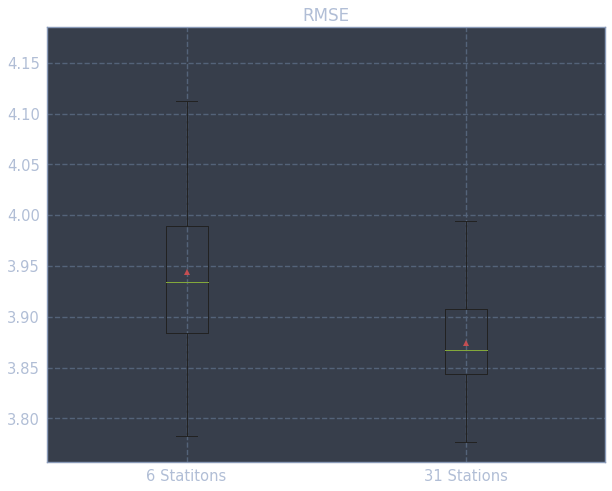

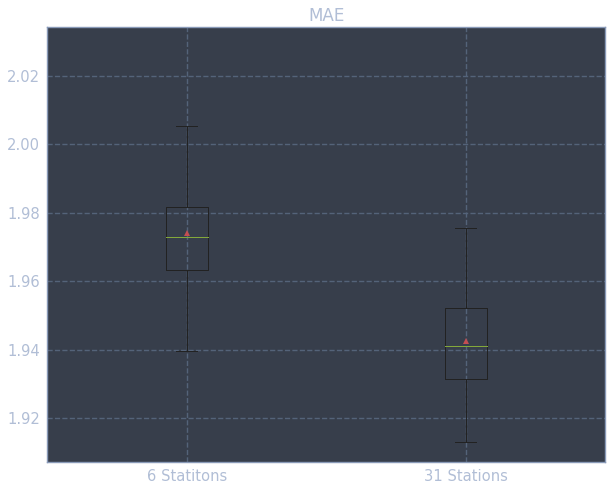

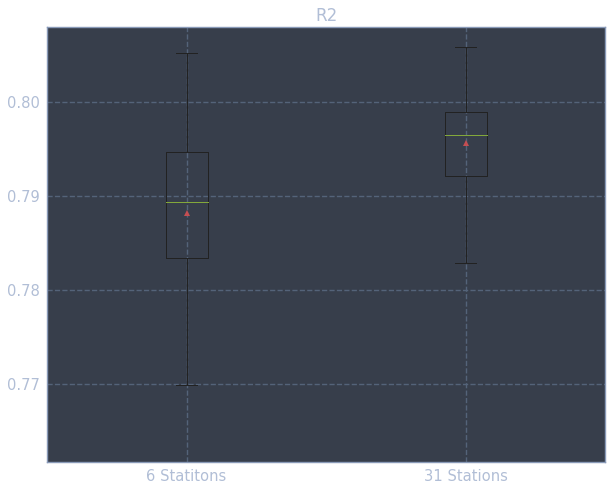

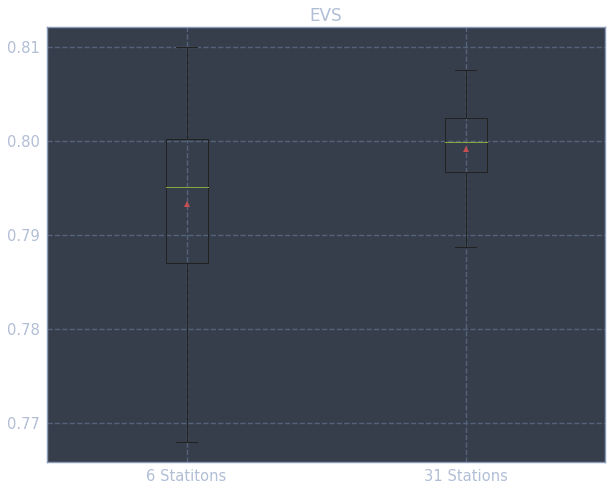

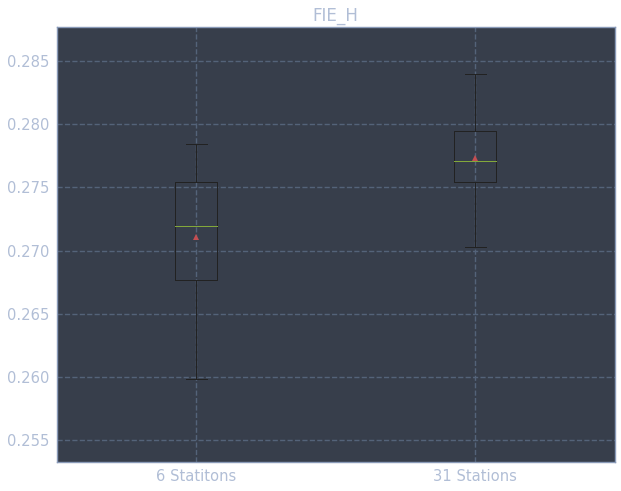

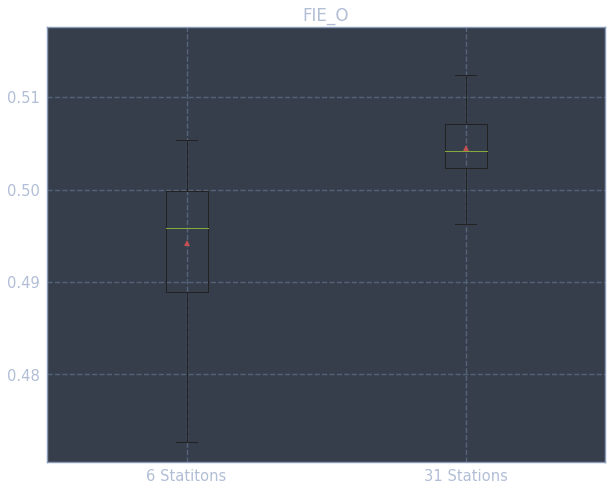

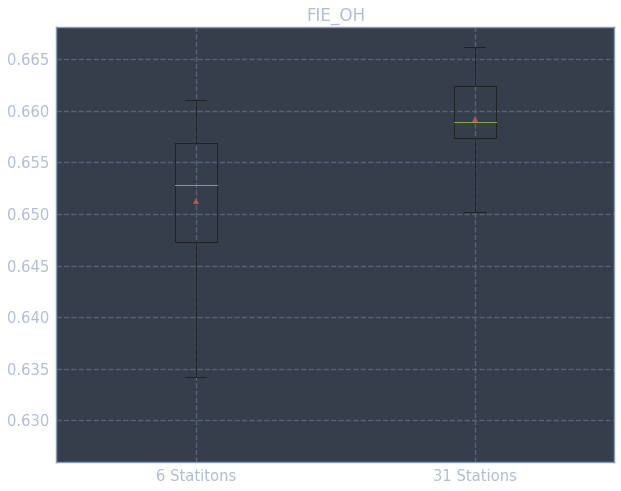

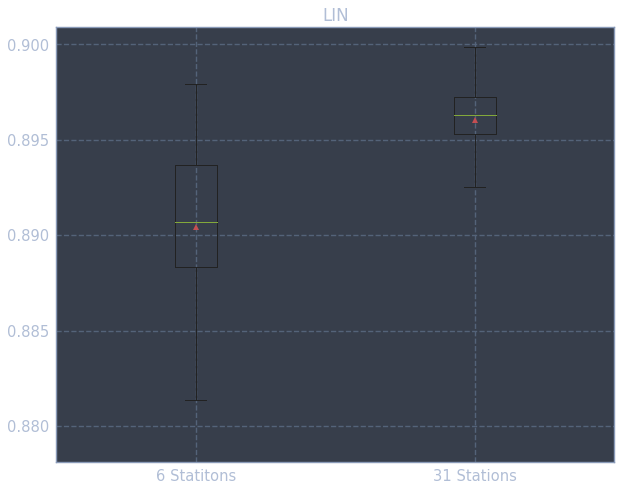

In [16]:
# I want a boxplot for each measure, showing test set comparison for 6station and 31station trained NNs
# plt.boxplot(x) makes a box for each column in x, so I need to feed 50x2 arrays to it

n = 0
for m in mess:
    plt.figure(n)
    exec(f'plt.boxplot({m}, labels=["6 Statitons", "31 Stations"], showmeans=True)')
    plt.title(m.upper())
    n += 1